## Importing Data Files

In [23]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [3]:
# Download latest version
path = kagglehub.competition_download('playground-series-s6e5')

print("Path to competition files:", path)

Path to competition files: C:\Users\EthanYongYuHeng\.cache\kagglehub\competitions\playground-series-s6e5


In [5]:

train = pd.read_csv(f"{path}/train.csv")
test = pd.read_csv(f"{path}/test.csv")

print(train.head())

   id Driver Compound                   Race  Year  PitStop  LapNumber  Stint  \
0   0   D109     HARD    Canadian Grand Prix  2022        0         50      2   
1   1   D086     HARD       Dutch Grand Prix  2025        1         27      2   
2   2    ZON     HARD    Austrian Grand Prix  2022        0         59      3   
3   3    SPE   MEDIUM     Pre-Season Testing  2023        0          2      1   
4   4   D019     HARD  Azerbaijan Grand Prix  2022        1         26      3   

   TyreLife  Position  LapTime (s)  LapTime_Delta  Cumulative_Degradation  \
0      39.0         8       78.491         -7.564                  21.019   
1       7.0         4       75.095        -32.617                -223.207   
2      22.0        13       70.945         -7.540                -100.529   
3       2.0         7       94.361         -7.324                  -7.324   
4       6.0         2      107.878          8.965                 -14.139   

   RaceProgress  Position_Change  PitNextLap  
0  

In [6]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  str    
 2   Compound                439140 non-null  str    
 3   Race                    439140 non-null  str    
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change         439140 

## Variable Categories
| Column                   | Type                             | Why                                  |
| ------------------------ | -------------------------------- | ------------------------------------ |
| `id`                     | Identifier                       | Unique row ID, not useful as feature |
| `Driver`                 | Categorical (nominal)            | Driver names/codes                   |
| `Compound`               | Categorical (nominal)            | HARD / MEDIUM / SOFT etc.            |
| `Race`                   | Categorical (nominal)            | Race/event name                      |
| `Year`                   | Numerical (discrete)             | Ordered integer year                 |
| `PitStop`                | Binary categorical               | 0 or 1                               |
| `LapNumber`              | Numerical (discrete ordinal)     | Ordered lap progression              |
| `Stint`                  | Ordinal categorical              | Ordered tyre stint number            |
| `TyreLife`               | Numerical (discrete)             | Tyre age in laps                     |
| `Position`               | Ordinal numerical                | Race ranking position                |
| `LapTime (s)`            | Numerical (continuous)           | Continuous time value                |
| `LapTime_Delta`          | Numerical (continuous)           | Difference in lap performance        |
| `Cumulative_Degradation` | Numerical (continuous)           | Engineered degradation metric        |
| `RaceProgress`           | Numerical (continuous)           | Normalized race percentage           |
| `Position_Change`        | Numerical (discrete signed)      | Gain/loss of positions               |
| `PitNextLap`             | Binary categorical (target-like) | Future pit indicator                 |


In [7]:
train.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


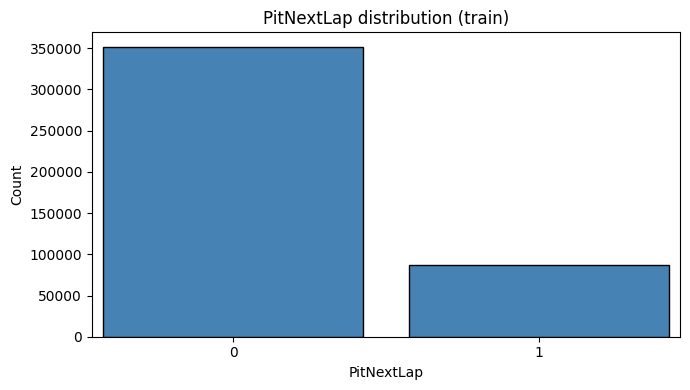

PitNextLap
0.0    0.801018
1.0    0.198982
Name: proportion, dtype: float64


In [8]:


fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(
    train["PitNextLap"],
    bins=np.arange(-0.5, 2, 1),
    edgecolor="black",
    rwidth=0.85,
    color="steelblue",
)
ax.set_xticks([0, 1])
ax.set_xlabel("PitNextLap")
ax.set_ylabel("Count")
ax.set_title("PitNextLap distribution (train)")
ax.margins(x=0.02)
plt.tight_layout()
plt.show()

print(train["PitNextLap"].value_counts(normalize=True).sort_index().rename("proportion"))

## **Target Variable Distribution — `PitNextLap`**

This shows that the dataset is **moderately imbalanced**, with **non-pit-stop laps** occurring approximately **four times more frequently** than pit-stop laps. Such imbalance is expected in Formula 1 race data because drivers spend the majority of laps remaining on track rather than entering the pits.

Due to this imbalance, relying solely on **accuracy** as an evaluation metric may produce misleading results. For example, a model that always predicts **“no pit stop”** would already achieve around **80% accuracy** despite completely failing to identify actual pit-stop events.

---

#  **Proposed Approach**

To address the class imbalance and build a reliable **pit stop prediction model**, the following approach will be used:

---

##  **1. Imbalance Handling**

Instead of immediately applying oversampling or undersampling techniques, **class weighting methods** will first be used so that pit-stop instances receive greater importance during training.

Examples include:

- **`class_weight="balanced"`** for sklearn-based models
- **`scale_pos_weight ≈ 4`** for boosting models such as **XGBoost** or **LightGBM**

This approach allows the model to learn minority-class patterns more effectively **without discarding valuable data** or generating synthetic samples.

---

##  **2. Model Selection**

Several **tree-based ensemble models** will be explored due to their strong performance on structured and tabular datasets:

- **XGBoost**
- **LightGBM**
- **Random Forest**

These models are well-suited for capturing complex race strategy patterns and non-linear relationships within the data.

---

##  **3. Evaluation Metrics**

Since **accuracy alone is insufficient** for imbalanced classification problems, evaluation will focus on more informative metrics such as:

- **Precision**
- **Recall**
- **F1-score**
- **ROC-AUC**
- **Confusion Matrix**

Special emphasis will be placed on **Recall** and **F1-score** for the pit-stop class to ensure the model can effectively identify actual pit-stop opportunities.

---

##  **4. Data Splitting Strategy**

To prevent **data leakage**, the dataset will **not** be randomly split by laps. Instead, the data will be divided either:

- **By race**, or
- **Chronologically**

This preserves the natural sequence of race events and ensures a more realistic evaluation of model performance in real-world race scenarios.

In [9]:
train.describe(include="all")

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140,439140,439140,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
unique,NaN,887,5,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,MAS,MEDIUM,Dutch Grand Prix,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1682,211141,24462,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,219569.500000,NaN,NaN,NaN,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,NaN,NaN,NaN,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,NaN,NaN,NaN,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,NaN,NaN,NaN,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,NaN,NaN,NaN,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,NaN,NaN,NaN,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000


In [10]:
## Feature Engineering

# Make copies to preserve original data
train_fe = train.copy()
test_fe = test.copy()

# Combine temporarily for consistent feature engineering
combined = pd.concat([train_fe, test_fe], axis=0, ignore_index=True)

# Drop Unused Columns 
combined.drop(columns=["id"], inplace=True)


## TYRE LIFE FEATURES

# Tyre wear category based on dataset distribution
combined["TyreWearCategory"] = pd.cut(
    combined["TyreLife"],
    bins=[0, 8, 18, 35, 80],
    labels=["Fresh", "Medium", "Old", "Critical"]
)

# Tyre life normalized
combined["TyreLife_Normalized"] = (
    combined["TyreLife"] / combined["TyreLife"].max()
)

# Degradation per tyre lap
combined["DegPerLap"] = (
    combined["Cumulative_Degradation"] /
    (combined["TyreLife"] + 1e-5)
)

## RACE PPHASE FEATURES

combined["RacePhase"] = pd.cut(
    combined["RaceProgress"],
    bins=[0, 0.33, 0.66, 1],
    labels=["Early", "Mid", "Late"]
)

# Late race indicator
combined["LateRace"] = (
    combined["RaceProgress"] >= 0.7
).astype(int)

## POSITION FEATURES

# Top 10 / points scoring zone
combined["PointsZone"] = (
    combined["Position"] <= 10
).astype(int)

# Podium position
combined["PodiumPosition"] = (
    combined["Position"] <= 3
).astype(int)

# Backmarker indicator
combined["Backmarker"] = (
    combined["Position"] >= 16
).astype(int)

# POSITION CHANGE FEATURES

# Losing positions
combined["LosingPositions"] = (
    combined["Position_Change"] < 0
).astype(int)

# Gaining positions
combined["GainingPositions"] = (
    combined["Position_Change"] > 0
).astype(int)

# Large position swings
combined["LargePositionChange"] = (
    combined["Position_Change"].abs() >= 5
).astype(int)


## STINT FEATURES

# Late stint indicator
combined["LateStint"] = (
    combined["Stint"] >= 3
).astype(int)

# Long stint indicator
combined["LongStintTyres"] = (
    combined["TyreLife"] >= 20
).astype(int)

## LAP TIME FEATURES

# Rolling lap time average by driver
combined["RollingLapTime_3"] = (
    combined.groupby("Driver")["LapTime (s)"]
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

# Rolling lap delta average
combined["RollingLapDelta_3"] = (
    combined.groupby("Driver")["LapTime_Delta"]
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

# Pace drop indicator
combined["PerformanceDrop"] = (
    combined["LapTime_Delta"] > 2
).astype(int)

# Severe pace drop indicator
combined["SeverePerformanceDrop"] = (
    combined["LapTime_Delta"] > 5
).astype(int)


## OUTLIER HANDLING

# Cap extreme lap times
combined["LapTime (s)"] = combined["LapTime (s)"].clip(
    lower=60,
    upper=300
)

# Cap LapTime_Delta
combined["LapTime_Delta"] = combined["LapTime_Delta"].clip(
    lower=-60,
    upper=60
)

# Cap cumulative degradation
combined["Cumulative_Degradation"] = combined[
    "Cumulative_Degradation"
].clip(
    lower=-300,
    upper=300
)

## ENCODE CATEGORICAL VARIABLES 

categorical_cols = [
    "Driver",
    "Compound",
    "Race",
    "TyreWearCategory",
    "RacePhase"
]

combined = pd.get_dummies(
    combined,
    columns=categorical_cols,
    drop_first=True
)


## Split back to Train/Test result

In [11]:
train_fe = combined.iloc[:len(train)].copy()
test_fe = combined.iloc[len(train):].copy()

print("Train Shape:", train_fe.shape)
print("Test Shape:", test_fe.shape)

print(train_fe.head())

Train Shape: (439140, 947)
Test Shape: (188165, 947)
   Year  PitStop  LapNumber  Stint  TyreLife  Position  LapTime (s)  \
0  2022        0         50      2      39.0         8       78.491   
1  2025        1         27      2       7.0         4       75.095   
2  2022        0         59      3      22.0        13       70.945   
3  2023        0          2      1       2.0         7       94.361   
4  2022        1         26      3       6.0         2      107.878   

   LapTime_Delta  Cumulative_Degradation  RaceProgress  ...  \
0         -7.564                  21.019      0.714286  ...   
1        -32.617                -223.207      0.346154  ...   
2         -7.540                -100.529      0.819444  ...   
3         -7.324                  -7.324      0.076923  ...   
4          8.965                 -14.139      0.361111  ...   

   Race_Saudi Arabian Grand Prix  Race_Singapore Grand Prix  \
0                          False                      False   
1              

## Separate Features and Target for Model Training

In [12]:
## Ensure train and test have same number and order of columns after encoding

train_fe, test_fe = train_fe.align(
    test_fe,
    join="left",
    axis=1,
    fill_value=0
)

In [13]:
X = train_fe.drop(columns=["PitNextLap"])
y = train_fe["PitNextLap"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## Random Forest Classifier

In [14]:
model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [15]:
y_pred = model.predict(X_valid)

print(classification_report(y_valid, y_pred))
print(confusion_matrix(y_valid, y_pred))

              precision    recall  f1-score   support

         0.0       0.92      0.95      0.93     70352
         1.0       0.75      0.67      0.71     17476

    accuracy                           0.89     87828
   macro avg       0.84      0.81      0.82     87828
weighted avg       0.89      0.89      0.89     87828

[[66492  3860]
 [ 5711 11765]]


## XGBoost Model

In [18]:
# Create XGBoost model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=4,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# Train model
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [19]:
# Predict
y_pred = xgb_model.predict(X_valid)
y_prob = xgb_model.predict_proba(X_valid)[:, 1]

# Evaluation
print(classification_report(y_valid, y_pred))

print(confusion_matrix(y_valid, y_pred))

print("ROC-AUC Score:", roc_auc_score(y_valid, y_prob))

              precision    recall  f1-score   support

         0.0       0.97      0.86      0.91     70352
         1.0       0.61      0.90      0.73     17476

    accuracy                           0.86     87828
   macro avg       0.79      0.88      0.82     87828
weighted avg       0.90      0.86      0.87     87828

[[60162 10190]
 [ 1695 15781]]
ROC-AUC Score: 0.944034589992693


## Feature Importance

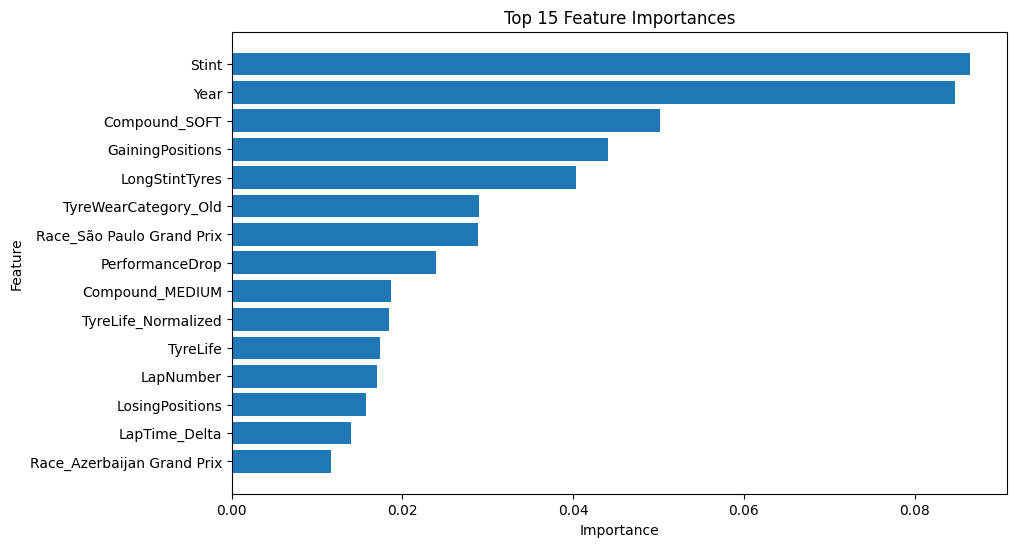

In [20]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances")

plt.show()

## LightBGM

In [24]:
# Handle imbalance
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# Create model
model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

# Train
model.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 69905, number of negative: 281407
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.101189 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3361
[LightGBM] [Info] Number of data points in the train set: 351312, number of used features: 649
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.198983 -> initscore=-1.392665
[LightGBM] [Info] Start training from score -1.392665


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,8
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [25]:
# Predict
y_pred = model.predict(X_valid)
y_prob = model.predict_proba(X_valid)[:, 1]

# Evaluation
print(classification_report(y_valid, y_pred))
print(confusion_matrix(y_valid, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_valid, y_prob))

              precision    recall  f1-score   support

         0.0       0.97      0.85      0.91     70352
         1.0       0.60      0.91      0.72     17476

    accuracy                           0.86     87828
   macro avg       0.79      0.88      0.82     87828
weighted avg       0.90      0.86      0.87     87828

[[59941 10411]
 [ 1654 15822]]
ROC-AUC Score: 0.9439334835459454


                   Feature  Importance
9             RaceProgress         780
4                 TyreLife         717
7            LapTime_Delta         635
0                     Year         621
8   Cumulative_Degradation         594
6              LapTime (s)         575
3                    Stint         505
2                LapNumber         480
5                 Position         378
10         Position_Change         374


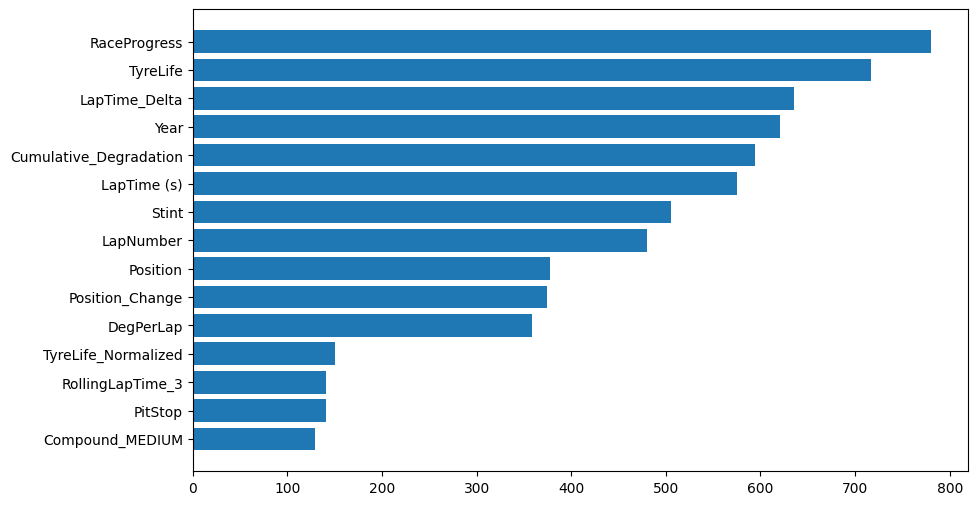

In [27]:
importance = model.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feat_imp.head(10))

plt.figure(figsize=(10,6))
plt.barh(feat_imp['Feature'][:15], feat_imp['Importance'][:15])
plt.gca().invert_yaxis()
plt.show()